# Replication of Figure 5: 2D Geometry of Truth Directions (Poulis et al., 2024)

This notebook replicates **Figure 5** and the cross-task generalization analysis from *Testing the Limits of Truth Directions in LLMs* (Poulis et al., 2024).

It extracts internal representations from **Layer 25** of LLaMA-3.1-8B-Instruct across all 9 complexity tasks (F0–F5 and A1–A3), projects them onto their learned truth directions and orthogonal max variance axes, and visualizes their geometric structures.

In [7]:
from huggingface_hub import notebook_login
notebook_login()

In [2]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

model_id = "meta-llama/Llama-3.1-8B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_id)

# Set padding settings
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = 'left'

# Load the full model, no pruning -- we have the GPU memory for it. Extracting via
# output_hidden_states=True and indexing hidden_states[25] directly gives the genuine
# raw (pre-final-norm) layer-25 residual stream, with no risk of the final RMSNorm or an
# off-by-one in layer count silently changing what's actually being read.
model = AutoModelForCausalLM.from_pretrained(
    model_id, 
    torch_dtype=torch.float16, 
    device_map="auto",
)

print("Loaded full FP16 model")

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the cpu.


Loaded full FP16 model


In [3]:
# Load all datasets
tasks = ["F0", "F1", "F2", "F3", "F4", "F5", "A1", "A2", "A3"]
datasets = {}

for task in tasks:
    train_df = pd.read_csv(f"../dataset/{task}_train.csv")
    test_df = pd.read_csv(f"../dataset/{task}_test.csv")
    datasets[task] = {"train": train_df, "test": test_df}

print(f"Loaded datasets for {len(tasks)} tasks.")


Loaded datasets for 9 tasks.


In [4]:
# Helper function to extract Layer 25 activations cleanly (Fast & Exact FP16)
def get_layer_25_activations(statements, batch_size=16):
    """
    Passes raw statements through the model and extracts the RAW (pre-final-norm) hidden
    state at the last token position for Layer 25, via output_hidden_states=True.
    hidden_states[25] is the output after 25 transformer blocks have run (hidden_states[0]
    is the embedding layer) -- the model's final RMSNorm is only ever applied to
    hidden_states[-1] (after all 32 blocks), so indexing 25 directly is always the raw,
    unnormalized residual stream, regardless of how many layers the model actually has.
    Returns a numpy array of shape (num_statements, hidden_size).
    """
    all_activations = []
    statements_list = list(statements)
    
    # Get the embedding device for input tensors
    embed_device = model.model.embed_tokens.weight.device
    
    for i in tqdm(range(0, len(statements_list), batch_size), desc="Extracting L25"):
        batch = statements_list[i:i+batch_size]
        
        # Raw text tokenization (No chat template, matching Poulis et al.)
        inputs = tokenizer(
            batch,
            return_tensors="pt",
            padding=True,
            truncation=True
        ).to(embed_device)
        
        with torch.no_grad():
            outputs = model.model(**inputs, output_hidden_states=True)

        layer25_hidden = outputs.hidden_states[25]
        # At index -1, it's the exact final token of every left-padded sequence
        last_token_acts = layer25_hidden[:, -1, :].detach().cpu().float().numpy()
        all_activations.append(last_token_acts)
        
    return np.vstack(all_activations)

In [5]:
import os
import pickle

if os.path.exists("extracted_activations.pkl") and os.path.exists("extracted_labels.pkl"):
    print("Loading cached activations and labels from disk...")
    with open("extracted_activations.pkl", "rb") as f:
        activations = pickle.load(f)
    with open("extracted_labels.pkl", "rb") as f:
        labels = pickle.load(f)
    print("Loaded successfully! You can skip the heavy extraction cell below.")
else:
    print("No cached activations found. You will need to run the extraction cell.")


No cached activations found. You will need to run the extraction cell.


In [6]:
# Extract Layer 25 Activations for all 9 tasks (Takes ~1-2 mins total)
layer_25_activations = {}

for task in tasks:
    print(f"--- Extracting Layer 25 for Task: {task} ---")
    
    train_stmts = datasets[task]["train"]["statement"]
    test_stmts = datasets[task]["test"]["statement"]
    
    layer_25_activations[task] = {
        "train": get_layer_25_activations(train_stmts, batch_size=16),
        "test": get_layer_25_activations(test_stmts, batch_size=16)
    }

print("Done extracting Layer 25 activations!")

--- Extracting Layer 25 for Task: F0 ---


Extracting L25: 100%|██████████| 32/32 [00:19<00:00,  1.63it/s]


--- Extracting Layer 25 for Task: F1 ---


Extracting L25: 100%|██████████| 32/32 [00:19<00:00,  1.64it/s]


--- Extracting Layer 25 for Task: F2 ---


...

--- Extracting Layer 25 for Task: A2 ---


Extracting L25: 100%|██████████| 19/19 [00:07<00:00,  2.44it/s]


--- Extracting Layer 25 for Task: A3 ---


Extracting L25: 100%|██████████| 19/19 [00:08<00:00,  2.35it/s]

Done extracting Layer 25 activations!


In [ ]:
# Replicate (b) Cross-task Generalization AUROC
num_layers = 32
auroc_results = {task: [] for task in tasks if task != "F0"}

for layer_idx in tqdm(range(num_layers), desc="Evaluating Layers"):
    # Train probe on F0 train at this layer
    X_train_f0 = activations["F0"]["train"][:, layer_idx, :]
    y_train_f0 = labels["F0"]["train"]
    
    probe = LogisticRegression(max_iter=1000)
    probe.fit(X_train_f0, y_train_f0)
    
    # Test on all other datasets
    for test_task in auroc_results.keys():
        X_test = activations[test_task]["test"][:, layer_idx, :]
        y_test = labels[test_task]["test"]
        
        # Predict probabilities
        y_prob = probe.predict_proba(X_test)[:, 1]
        
        # Calculate AUROC
        try:
            score = roc_auc_score(y_test, y_prob)
        except ValueError:
            # Handle case where all labels are the same (shouldn't happen in proper splits)
            score = 0.5
            
        auroc_results[test_task].append(score)


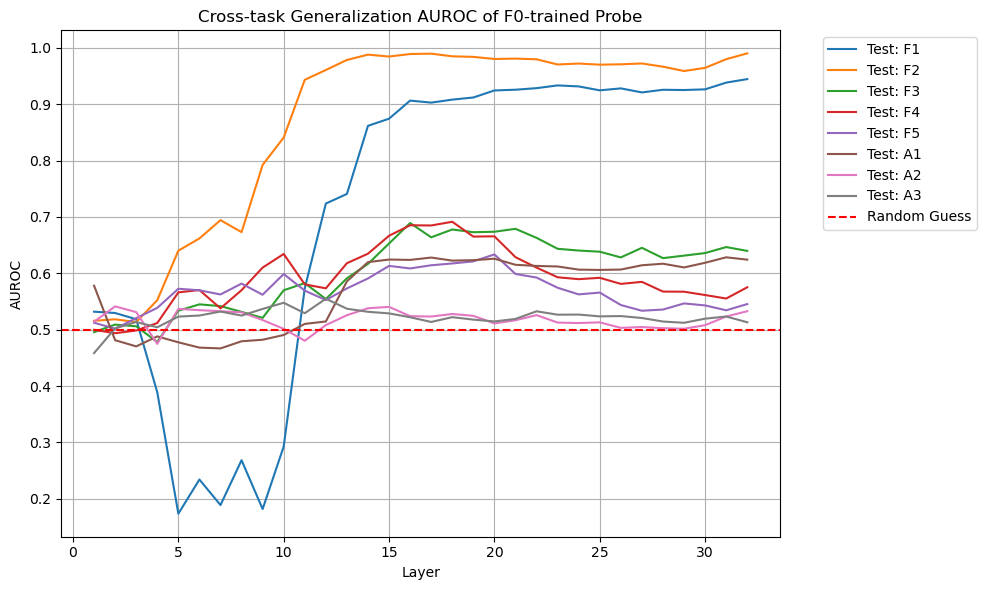

In [ ]:
plt.figure(figsize=(10, 6))

for test_task, scores in auroc_results.items():
    plt.plot(range(1, num_layers + 1), scores, label=f"Test: {test_task}")

plt.title("Cross-task Generalization AUROC of F0-trained Probe")
plt.xlabel("Layer")
plt.ylabel("AUROC")
plt.axhline(y=0.5, color='r', linestyle='--', label="Random Guess")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


## Figure 5 Replication: 2D Projections at Layer 25

### Core Methodology & Design Choices
To faithfully replicate the representations from the paper, five key design choices are implemented:

1. **Independent Per-Task Probes**: Rather than assuming a single universal truth direction, each task fits its own logistic regression probe on its training set at Layer 25 to identify the specific direction that best separates True vs. False for that task.
2. **Raw Statement Prompting**: Statements are tokenized directly without chat-template formatting (e.g. `<|start_header_id|>...`), ensuring the representation captures the final token of the factual/arithmetic statement itself.
3. **Exact Token Alignment (Left Padding)**: Using left-padding ensures the true final token of every statement is consistently aligned at index `[:, -1, :]` without padding offsets.
4. **Normalized Orthogonal Subspace Projection**: Projections are made onto the unit truth vector $\hat{v}$, and PCA is fitted strictly to the orthogonal complement $\mathbf{X}_{\perp} = \mathbf{X} - (\mathbf{X} \cdot \hat{v})\hat{v}$.
5. **Full Distribution Plotting**: Plotting both train and test splits together provides the sample density needed to reveal the continuous geometric manifolds (such as the F0 V-shape, F1 diagonal streaks, F2 crescent curve, A1 operation quadrants, and F5 linear collapse).

In [12]:
# labels dict, needed by both the Figure 5 cells and the cross-task cell below -- built
# directly from the already-loaded CSVs, no model needed.
labels = {
    task: {
        "train": datasets[task]["train"]["label"].to_numpy(),
        "test": datasets[task]["test"]["label"].to_numpy(),
    }
    for task in tasks
}


In [13]:
import torch.nn as nn

def fit_linear_probe(X_train, y_train, device="cuda" if torch.cuda.is_available() else "cpu"):
    """No-bias, train-mean-centered linear probe -- matches the paper's Appendix A.4 exactly
    (Adam, lr=1e-3, weight_decay=0.1, 1000 steps, BCEWithLogitsLoss, no bias term). Replaces
    sklearn's LogisticRegression (free intercept, no train-mean centering) so this probe
    uses the same methodology as train_probe_pytorch elsewhere in the project.
    Returns (w, train_mean) -- for a point x, the logit is (x - train_mean) @ w."""
    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    train_mean = X_train_t.mean(dim=0)
    X_centered = (X_train_t - train_mean).to(device)
    y_t = torch.tensor(y_train, dtype=torch.float32).to(device)

    probe = nn.Linear(X_train.shape[1], 1, bias=False).to(device)
    optimizer = torch.optim.Adam(probe.parameters(), lr=1e-3, weight_decay=0.1)
    loss_fn = nn.BCEWithLogitsLoss()

    for _ in range(1000):
        optimizer.zero_grad()
        logits = probe(X_centered).squeeze(-1)
        loss = loss_fn(logits, y_t)
        loss.backward()
        optimizer.step()

    w = probe.weight.detach().cpu().numpy().flatten()
    return w, train_mean.numpy()

In [14]:
# Replicate Figure 5: Compute 2D Projections at Layer 25
projection_data = {}

for task in tasks:
    # 1. Train probe on this task's train set at Layer 25
    X_train = layer_25_activations[task]["train"]
    y_train = labels[task]["train"]

    w, train_mean = fit_linear_probe(X_train, y_train)
    truth_direction = w / np.linalg.norm(w)

    # 2. Combine train and test sets to project full distribution (all dots)
    X_test = layer_25_activations[task]["test"]
    y_test = labels[task]["test"]

    X_all = np.vstack([X_train, X_test])
    y_all = np.concatenate([y_train, y_test])

    # Center the data (combined train+test mean, for a symmetric plot -- the probe itself
    # was already trained with train-only centering above, per the paper's methodology)
    X_centered = X_all - X_all.mean(axis=0)

    # X-axis (Truth Direction): Project onto normalized truth direction
    truth_coords = X_centered @ truth_direction

    # Y-axis (Orthogonal Max Variance): Remove truth direction component, then fit PCA
    X_orthogonal = X_centered - np.outer(truth_coords, truth_direction)
    pca = PCA(n_components=1, random_state=42)
    ortho_coords = pca.fit_transform(X_orthogonal).flatten()

    projection_data[task] = {
        "truth_axis": truth_coords,   # Horizontal
        "ortho_axis": ortho_coords,   # Vertical
        "label": y_all
    }

print("Projections computed successfully!")

Projections computed successfully!


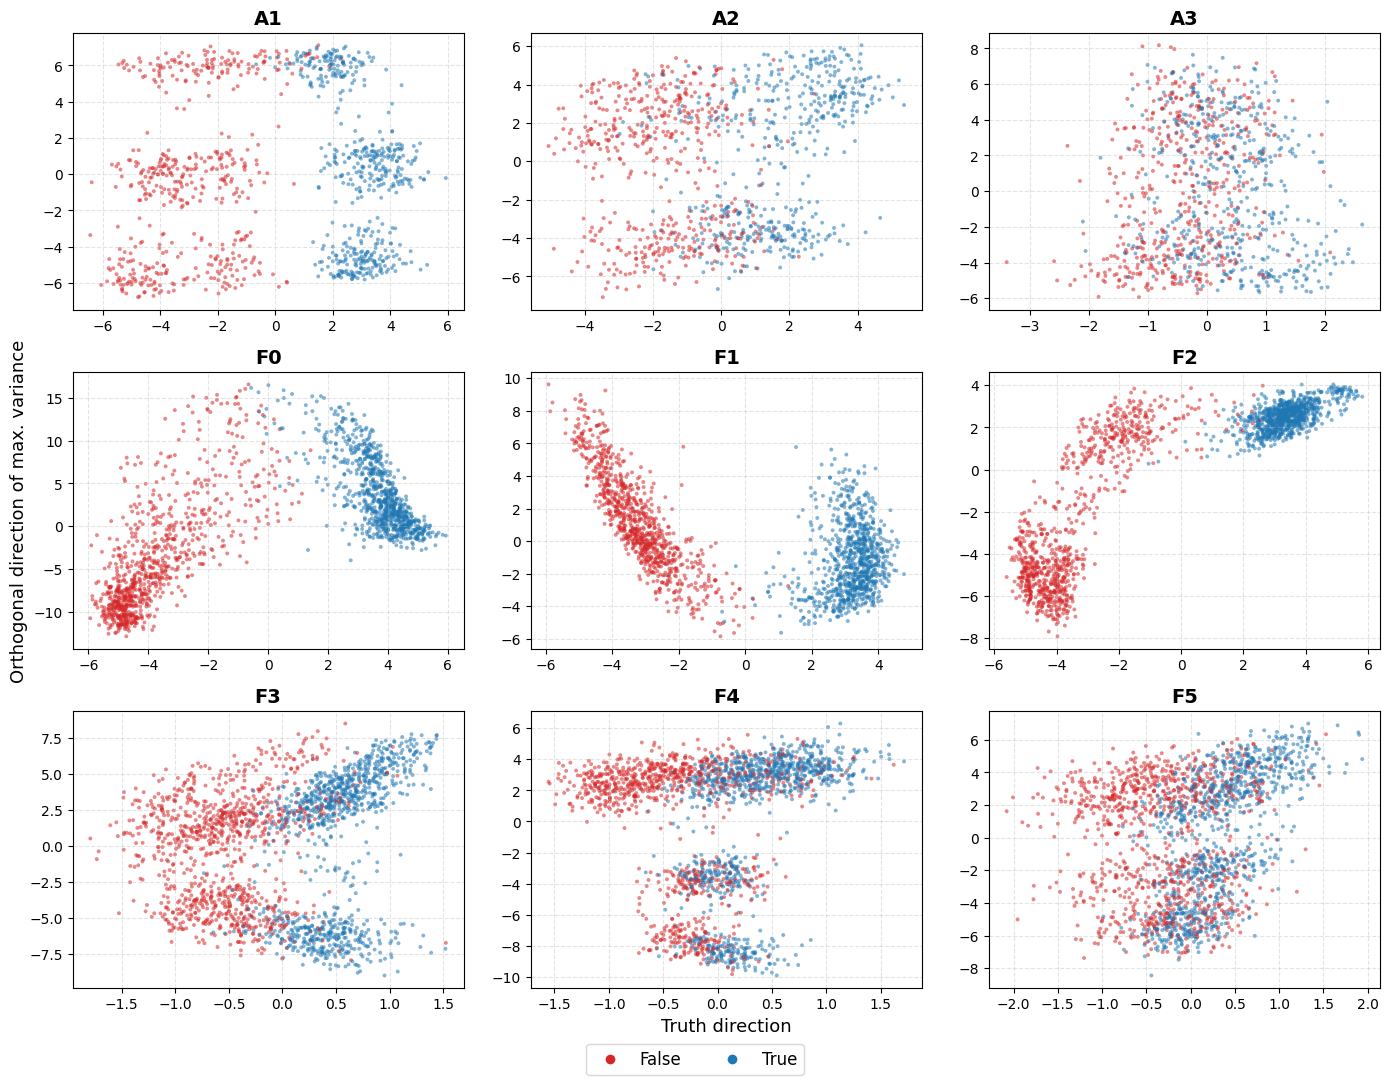

In [15]:
# Plot Figure 5: 3x3 Grid Matching the Paper
fig, axes = plt.subplots(3, 3, figsize=(14, 11))

# Grid layout: Row 1: A1, A2, A3; Row 2: F0, F1, F2; Row 3: F3, F4, F5
grid_tasks = [
    ["A1", "A2", "A3"],
    ["F0", "F1", "F2"],
    ["F3", "F4", "F5"]
]

for row_idx in range(3):
    for col_idx in range(3):
        task = grid_tasks[row_idx][col_idx]
        ax = axes[row_idx, col_idx]
        data = projection_data[task]
        
        # Color True as Blue (#1f77b4), False as Red (#d62728)
        colors = np.where(data["label"] == 1, '#1f77b4', '#d62728')
        
        ax.scatter(data["truth_axis"], data["ortho_axis"], c=colors, alpha=0.55, s=8, edgecolors='none')
        ax.set_title(task, fontsize=14, fontweight='bold')
        ax.grid(True, linestyle='--', alpha=0.35)
        
        if col_idx == 0 and row_idx == 1:
            ax.set_ylabel("Orthogonal direction of max. variance", fontsize=13)
        if row_idx == 2 and col_idx == 1:
            ax.set_xlabel("Truth direction", fontsize=13)

# Legend at bottom
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='False', markerfacecolor='#d62728', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='True', markerfacecolor='#1f77b4', markersize=8)
]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, bbox_to_anchor=(0.5, 0.01), fontsize=12)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

In [ ]:
import pickle

# Save the activations and labels to disk
with open('extracted_activations.pkl', 'wb') as f:
    pickle.dump(activations, f)
    
with open('extracted_labels.pkl', 'wb') as f:
    pickle.dump(labels, f)

print("Saved to disk successfully!")


Saved to disk successfully!
